### # 📊 Análise de Ações Brasileiras

Este projeto analisa o desempenho de ações brasileiras em comparação ao Ibovespa, avaliando retorno, risco e eficiência de portfólio.

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

tickers = [
    "ALOS3.SA", "BBAS3.SA", "BBSE3.SA",
    "BRBI11.SA", "CMIG4.SA", "CXSE3.SA",
    "LEVE3.SA", "^BVSP"
]

dados = yf.download(tickers, start="2021-01-01", end="2025-12-31")['Close']
dados.dropna(inplace=True) # inplace=True para modificar o DataFrame original
display(dados.head())

[*********************100%***********************]  8 of 8 completed


Ticker,ALOS3.SA,BBAS3.SA,BBSE3.SA,BRBI11.SA,CMIG4.SA,CXSE3.SA,LEVE3.SA,^BVSP
Date,,,,,,,,
2021-07-14,24.378239,11.242258,14.512402,13.394511,3.847053,7.819066,16.519657,128407.0
2021-07-15,24.113798,11.070251,14.267385,13.655869,3.809026,7.551808,16.250263,127468.0
2021-07-16,23.783243,10.936088,14.135454,13.590527,3.780507,7.305106,16.199430,125960.0
2021-07-19,23.560118,10.853526,13.903006,13.518654,3.761492,7.078963,15.965614,124395.0
2021-07-20,24.055952,11.046170,13.934419,14.087104,3.847053,7.113226,16.021528,125401.0


### Tratamento dos Dados

In [68]:
dados_anuais = dados.resample('YE').last()
retornos_anuais = dados_anuais.pct_change().dropna()
display(retornos_anuais)

Ticker,ALOS3.SA,BBAS3.SA,BBSE3.SA,BRBI11.SA,CMIG4.SA,CXSE3.SA,LEVE3.SA,^BVSP
Date,,,,,,,,
2022-12-31,-0.214681,0.349569,0.749028,-0.120191,0.319675,0.077398,0.178321,0.049694
2023-12-31,0.605552,0.734926,0.106964,0.429583,0.151025,0.702136,0.625665,0.219520
2024-12-31,-0.265149,-0.054091,0.159224,-0.020851,0.421753,0.185055,-0.162130,-0.103603
2025-12-31,0.660980,-0.049395,0.122655,0.691954,0.175002,0.271200,0.357507,0.339549


### ANÁLISE EXPLORATÓRIA

In [61]:
# Estatísticas
retornos_anuais.describe()

# Correlação
# correlacao = retornos_anuais.corr()
# sns.heatmap(correlacao, annot=True)


Ticker,ALOS3.SA,BBAS3.SA,BBSE3.SA,BRBI11.SA,CMIG4.SA,CXSE3.SA,LEVE3.SA,^BVSP
count,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000
mean,0.196676,0.245252,0.284468,0.245124,0.266864,0.308947,0.249841,0.126290
std,0.505059,0.377309,0.310480,0.382047,0.127328,0.273853,0.330490,0.193984
min,-0.265149,-0.054091,0.106964,-0.120191,0.151025,0.077398,-0.162130,-0.103603
25%,-0.227298,-0.050569,0.118732,-0.045686,0.169008,0.158141,0.093208,0.011370
50%,0.195435,0.150087,0.140939,0.204366,0.247339,0.228128,0.267914,0.134607
75%,0.619409,0.445908,0.306675,0.495176,0.345194,0.378934,0.424547,0.249527
max,0.660980,0.734926,0.749028,0.691954,0.421753,0.702136,0.625665,0.339549


### Desempenho

Ticker,ALOS3.SA,BBAS3.SA,BBSE3.SA,BRBI11.SA,CMIG4.SA,CXSE3.SA,LEVE3.SA,^BVSP
Date,,,,,,,,
2022-12-31,0.785319,1.349569,1.749028,0.879809,1.319675,1.077398,1.178321,1.049694
2023-12-31,1.260870,2.341402,1.936112,1.257760,1.518978,1.833878,1.915556,1.280122
2024-12-31,0.926552,2.214753,2.244387,1.231535,2.159611,2.173247,1.604986,1.147498
2025-12-31,1.538984,2.105356,2.519672,2.083700,2.537549,2.762632,2.178780,1.537130


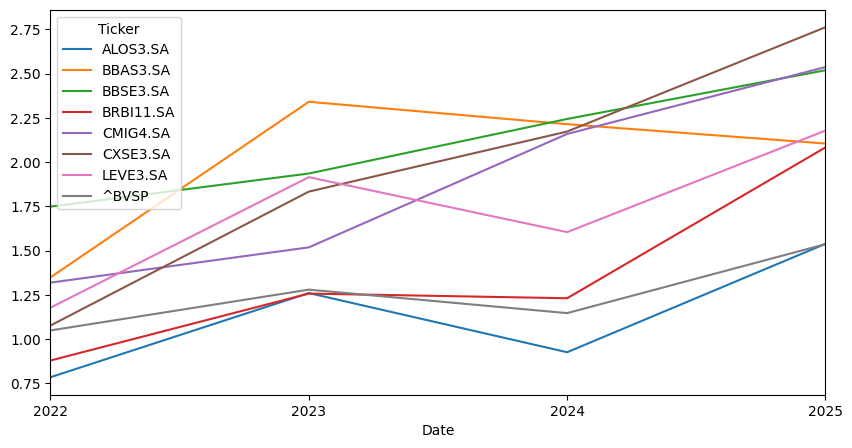

In [ ]:
# Retorno acumulativo
retornos_acumulados = (1 + retornos_anuais).cumprod()
retornos_acumulados.plot(figsize=(10,5))

retornos_acumulados = (1 + retornos_anuais).cumprod()
display(retornos_acumulados)

### Observa-se crescimento consistente em alguns ativos, com destaque para aqueles que superaram o índice de referência.

In [77]:
# Volatilidade
volatilidade = retornos_anuais.std() # Desvio padrão como medida de volatilidade
display(volatilidade)

# Ativos com maior volatilidade apresentam maior risco, podendo oferecer maiores retornos, mas com maior incerteza.

Ticker
ALOS3.SA     0.505059
BBAS3.SA     0.377309
BBSE3.SA     0.310480
BRBI11.SA    0.382047
CMIG4.SA     0.127328
CXSE3.SA     0.273853
LEVE3.SA     0.330490
^BVSP        0.193984
dtype: float64

In [76]:
# Sharpe
sharpe = retornos_anuais.mean() / retornos_anuais.std()
sharpe.sort_values(ascending=False)
display(sharpe)

# O índice de Sharpe evidencia quais ativos entregam melhor retorno ajustado ao risco.

Ticker
ALOS3.SA     0.389411
BBAS3.SA     0.650004
BBSE3.SA     0.916220
BRBI11.SA    0.641606
CMIG4.SA     2.095883
CXSE3.SA     1.128151
LEVE3.SA     0.755970
^BVSP        0.651033
dtype: float64

In [ ]:
# Drawdown
cum = (1 + retornos_anuais).cumprod()
drawdown = cum / cum.cummax() - 1
drawdown.min()
display(drawdown)

# drawdown representa a maior queda percentual do valor do investimento em relação ao seu pico anterior, indicando o risco de perda máxima.

Ticker,ALOS3.SA,BBAS3.SA,BBSE3.SA,BRBI11.SA,CMIG4.SA,CXSE3.SA,LEVE3.SA,^BVSP
Date,,,,,,,,
2022-12-31,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.00000,0.000000
2023-12-31,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.00000,0.000000
2024-12-31,-0.265149,-0.054091,0.0,-0.020851,0.0,0.0,-0.16213,-0.103603
2025-12-31,0.000000,-0.100814,0.0,0.000000,0.0,0.0,0.00000,0.000000


### Risco

In [ ]:
# Beta
cov = retornos_anuais.cov()
var_bvsp = retornos_anuais['^BVSP'].var()
beta = cov['^BVSP'] / var_bvsp
display(beta)

# O beta indica a sensibilidade do ativo em relação ao mercado. Beta > 1 indica maior volatilidade que o mercado, enquanto Beta < 1 indica menor volatilidade.

Ticker
ALOS3.SA     2.434382
BBAS3.SA     0.386598
BBSE3.SA    -0.512428
BRBI11.SA    1.785958
CMIG4.SA    -0.620459
CXSE3.SA     0.662816
LEVE3.SA     1.401254
^BVSP        1.000000
Name: ^BVSP, dtype: float64

In [ ]:
# VAR
var_95 = retornos_anuais.quantile(0.05) # Quantil de 5% para VaR a 95%
display(var_95)

# O Value at Risk (VaR) a 95% indica a perda máxima esperada em um dia, com 95% de confiança. Por exemplo, um VaR de -0.02 significa que há 5% de chance de perder mais de 2% em um dia.

Ticker
ALOS3.SA    -0.257578
BBAS3.SA    -0.053387
BBSE3.SA     0.109318
BRBI11.SA   -0.105290
CMIG4.SA     0.154621
CXSE3.SA     0.093547
LEVE3.SA    -0.111063
^BVSP       -0.080609
Name: 0.05, dtype: float64

### BENCHMARK

In [ ]:
# Comparação com índice
retornos_anuais.sub(retornos_anuais['^BVSP'], axis=0)

#  Permite identificar ativos que superaram o mercado (alpha positivo).

Ticker,ALOS3.SA,BBAS3.SA,BBSE3.SA,BRBI11.SA,CMIG4.SA,CXSE3.SA,LEVE3.SA,^BVSP
Date,,,,,,,,
2022-12-31,-0.264375,0.299875,0.699335,-0.169885,0.269981,0.027705,0.128627,0.0
2023-12-31,0.386032,0.515406,-0.112555,0.210064,-0.068495,0.482616,0.406145,0.0
2024-12-31,-0.161545,0.049512,0.262827,0.082752,0.525356,0.288658,-0.058527,0.0
2025-12-31,0.321431,-0.388944,-0.216894,0.352405,-0.164547,-0.068349,0.017958,0.0


In [82]:
# Ranking
retornos_anuais.mean().sort_values(ascending=False)

Ticker
CXSE3.SA     0.308947
BBSE3.SA     0.284468
CMIG4.SA     0.266864
LEVE3.SA     0.249841
BBAS3.SA     0.245252
BRBI11.SA    0.245124
ALOS3.SA     0.196676
^BVSP        0.126290
dtype: float64

## PORTFÓLIO (DIFERENCIAL)

In [87]:
retorno_esperado = retornos_anuais.mean()
cov_matrix = retornos_anuais.cov()

pesos = np.random.random(len(retornos_anuais.columns))
pesos /= np.sum(pesos)

retorno_port = np.dot(pesos, retorno_esperado)
risco_port = np.sqrt(np.dot(pesos.T, np.dot(cov_matrix, pesos)))
print(f"Retorno esperado do portfólio: {retorno_port:.4f}")
print(f"Risco do portfólio: {risco_port:.4f}")

Retorno esperado do portfólio: 0.2392
Risco do portfólio: 0.1935


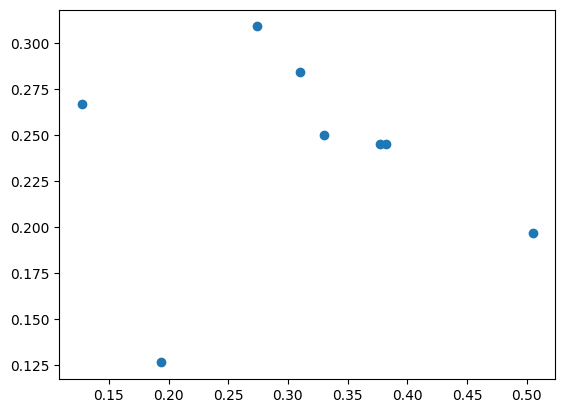

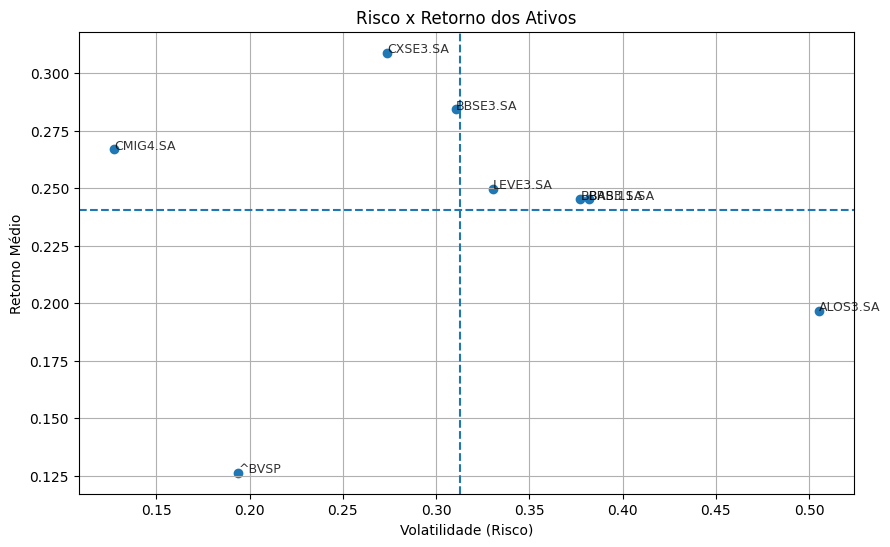

In [89]:
# GRÁFICO RISCO x RETORNO

plt.scatter(volatilidade, retornos_anuais.mean())

media_retornos = retornos_anuais.mean()

plt.figure(figsize=(10,6))

# Scatter
plt.scatter(volatilidade, media_retornos)

# Labels dos pontos
for ativo in retornos_anuais.columns:
    plt.annotate(
        ativo,
        (volatilidade.loc[ativo], media_retornos.loc[ativo]),
        fontsize=9,
        alpha=0.8
    )

# Linha vertical (risco médio)
plt.axvline(volatilidade.mean(), linestyle='--')

# Linha horizontal (retorno médio)
plt.axhline(media_retornos.mean(), linestyle='--')

# Títulos e labels
plt.title('Risco x Retorno dos Ativos')
plt.xlabel('Volatilidade (Risco)')
plt.ylabel('Retorno Médio')

plt.grid(True)
plt.show()